## Enrichment or depletion of spatial factors in cortical layers

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import scipy.io
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings("ignore")

### Load results

In [2]:
res_dir = "Results/INSPIRE_DLPFC"
adata = sc.read_h5ad(res_dir + "/adata_inspire.h5ad")
basis_df = pd.read_csv(res_dir + "/basis_df_inspire.csv", index_col=0)

### Enrichment or depletion analysis

In [3]:
layer_list = list(sorted(set(adata.obs["layer"])))
n_layer = len(layer_list)
n_topic = 20
layer_prop = np.zeros((n_layer, n_topic))
for i, layer_name in enumerate(layer_list):
    adata_tmp = adata[adata.obs["layer"] == layer_name, :].copy()
    prop_tmp = adata_tmp.obs[["proportion-"+str(i) for i in range(n_topic)]]
    layer_prop[i, :] = list(np.mean(prop_tmp, axis=0))

In [4]:
import random
random.seed(1234)

n_try = 1000
permuted = np.zeros((layer_prop.shape[0], layer_prop.shape[1], n_try))
prop_df = adata.obs[["proportion-"+str(i) for i in range(n_topic)]]
layer = adata.obs["layer"].values.astype(str)

for p in range(n_try):
    region_props = np.ones((n_layer, n_topic))
    for j, layer_name in enumerate(layer_list):
        idx = np.arange(prop_df.shape[0])
        random.shuffle(idx)
        prop_permute = prop_df.iloc[idx, :]
        prop_region = prop_permute.loc[layer==layer_name, :]
        region_props[j, :] = np.mean(prop_region, axis=0)
    permuted[:,:,p] = layer_prop - region_props

In [5]:
diff = np.mean(permuted, axis=2) / np.std(permuted, axis=2)

In [6]:
diff = diff[[0,1,4,5], :]
diff = diff[:, [16,17,19]]

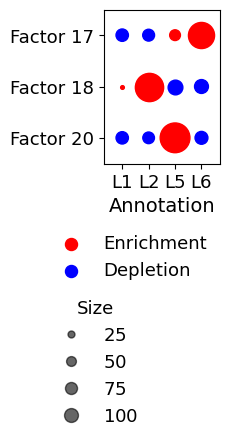

In [7]:
f, ax = plt.subplots(figsize=(1.5,2))
n_topic = diff.shape[1]
n_layer = diff.shape[0]

for j in range(n_layer):
    y = diff[j, :]
    if j==0:
        plt.scatter((np.ones(n_topic)*j)[y>0], np.arange(n_topic)[y>0], c="red", s=y[y>0]*5, label="Enrichment")
        plt.scatter((np.ones(n_topic)*j)[y<0], np.arange(n_topic)[y<0], c="blue", s=-y[y<0]*5, label="Depletion")
    else:
        plt.scatter((np.ones(n_topic)*j)[y>0], np.arange(n_topic)[y>0], c="red", s=y[y>0]*5)
        plt.scatter((np.ones(n_topic)*j)[y<0], np.arange(n_topic)[y<0], c="blue", s=-y[y<0]*5)
    
plt.yticks(np.arange(diff.shape[1]), ["Factor 17","Factor 18","Factor 20"], rotation=0, fontsize=13)
plt.xticks(np.arange(diff.shape[0]), ["L1","L2","L5","L6"], rotation=0, fontsize=13)
plt.xlim(-0.7, n_layer-0.3)
plt.ylim(2.5, -0.5)

scatter = plt.scatter([0, 0, 0, 0], [0, 0, 0, 0], c="white", alpha=0, s=[25, 50, 75, 100])
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend2 = ax.legend(handles, labels, title="Size", prop={"size": 13}, loc=(-0.5, -1.75), frameon=False)
plt.xlabel("Annotation", fontsize=14)
plt.setp(legend2.get_title(),fontsize=13)

f.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.scatter([], [], c="red", s=75, label="Enrichment")
plt.scatter([], [], c="blue", s=75, label="Depletion")
lgnd = plt.legend(scatterpoints=1, loc=(-0.5, -0.8), frameon=False, prop={"size": 13})
plt.rcParams['legend.title_fontsize'] = 13

plt.show()